# Notebook 1: Data Profiling & Cleaning 
**Dataset:** Sample Superstore

**Goal:** Inspect the raw data, fix quality issues,engineer base features, and save clean dataset for analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 1: Load Data

In [2]:
df = pd.read_csv('../data/raw/Sample - Superstore.csv', encoding='latin-1', dtype={'Postal Code': 'string'})

print(df.shape)
print(df.columns.tolist())
df.head()


(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


## Section 2: Data Types Audit

In [4]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date               object
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code      string[python]
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Section 3: Fix Data Types


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)
print(df['Postal Code'].dtype)





datetime64[ns]
datetime64[ns]
string


## Section 4: Missing Values


In [6]:
df.isnull().sum()



Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.isnull().sum() / len(df) * 100


Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

**Finding:** No missing values detected across all 21 columns (0%)
Dataset is complete - no imputation required

## Section 5: Duplicate Check

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.duplicated(subset=['Order ID', 'Product ID']).sum()


np.int64(8)

In [10]:
dupes = df[df.duplicated(subset=['Order ID', 'Product ID'], keep=False)]
dupes.sort_values(['Order ID', 'Product ID'])


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6498,6499,CA-2015-103135,2015-07-24,2015-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,Louisville,...,40214,South,OFF-BI-10000069,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",135.090,9,0.0,62.1414
6500,6501,CA-2015-103135,2015-07-24,2015-07-28,Standard Class,SS-20515,Shirley Schmidt,Home Office,United States,Louisville,...,40214,South,OFF-BI-10000069,Office Supplies,Binders,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",90.060,6,0.0,41.4276
350,351,CA-2016-129714,2016-09-01,2016-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,24.560,2,0.0,11.5432
352,353,CA-2016-129714,2016-09-01,2016-09-03,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,10009,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,49.120,4,0.0,23.0864
1300,1301,CA-2016-137043,2016-12-23,2016-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.760,6,0.0,166.1004
1301,1302,CA-2016-137043,2016-12-23,2016-12-25,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,22153,South,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",286.380,3,0.0,83.0502
9168,9169,CA-2016-140571,2016-03-15,2016-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,Jackson,...,39212,South,OFF-PA-10001954,Office Supplies,Paper,Xerox 1964,319.760,14,0.0,147.0896
9169,9170,CA-2016-140571,2016-03-15,2016-03-19,Standard Class,SJ-20125,Sanjit Jacobs,Home Office,United States,Jackson,...,39212,South,OFF-PA-10001954,Office Supplies,Paper,Xerox 1964,45.680,2,0.0,21.0128
7881,7882,CA-2017-118017,2017-12-03,2017-12-06,Second Class,LC-16870,Lena Cacioppo,Consumer,United States,Thornton,...,80229,West,TEC-AC-10002006,Technology,Accessories,Memorex Micro Travel Drive 16 GB,76.752,6,0.2,10.5534
7882,7883,CA-2017-118017,2017-12-03,2017-12-06,Second Class,LC-16870,Lena Cacioppo,Consumer,United States,Thornton,...,80229,West,TEC-AC-10002006,Technology,Accessories,Memorex Micro Travel Drive 16 GB,102.336,8,0.2,14.0712


In [11]:
df[(df['Order ID'] == 'US-2014-150119') & (df['Product ID'] == 'FUR-CH-10002965')]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3405,3406,US-2014-150119,2014-04-23,2014-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
3406,3407,US-2014-150119,2014-04-23,2014-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


**Finding:** 8 logical duplicates found on Order ID + Product ID. 
Investigation shows most are split line items (same product, different quantities — legitimate). 
One true duplicate identified: US-2014-150119 / FUR-CH-10002965 — identical rows.
Decision: Retain split line items. Flag true duplicate for removal in processing step.


## Section 6: Remove True Duplicate


In [12]:
df = df.drop_duplicates(subset=['Order ID', 'Product ID', 'Sales', 'Quantity', 'Profit'])
print(df.shape)


(9993, 21)


## Section 7: Outlier Detection

In [13]:
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe()


,Sales,Profit,Quantity,Discount
count,9993.000000,9993.000000,9993.000000,9993.000000
mean,229.852846,28.660971,3.789753,0.156188
std,623.276074,234.271476,2.225149,0.206457
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.731000,2.000000,0.000000
50%,54.480000,8.671000,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


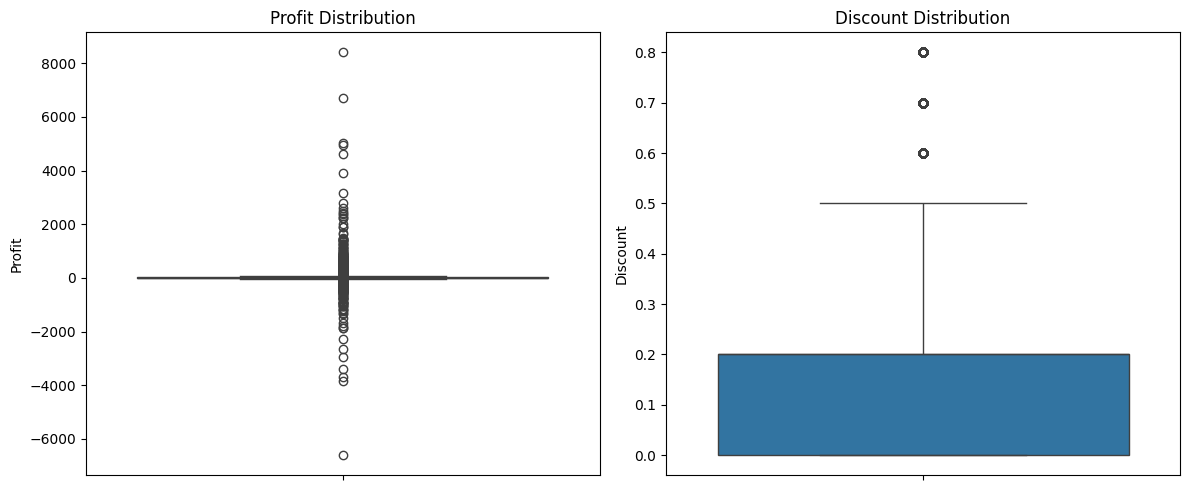

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Profit'], ax=axes[0])
axes[0].set_title('Profit Distribution')

sns.boxplot(y=df['Discount'], ax=axes[1])
axes[1].set_title('Discount Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/01_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Profit has significant outliers in both directions — gains up to $8,000 
and losses exceeding $6,000. Discount outliers at 60–80% are likely driving extreme 
profit losses. These are retained for analysis — they represent the core business problem.


## Section 8: Feature Engineering

In [15]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin'] = df['Profit'] / df['Sales']

df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Shipping Days', 'Profit Margin']].head()



,Order Date,Ship Date,Order Year,Order Month,Shipping Days,Profit Margin
0,2016-11-08,2016-11-11,2016,11,3,0.1600
1,2016-11-08,2016-11-11,2016,11,3,0.3000
2,2016-06-12,2016-06-16,2016,6,4,0.4700
3,2015-10-11,2015-10-18,2015,10,7,-0.4000
4,2015-10-11,2015-10-18,2015,10,7,0.1125


**Feature Engineering:** Added 4 derived columns:
- `Order Year` / `Order Month` — extracted from Order Date for time series analysis
- `Shipping Days` — days between order and delivery, for operational analysis  
- `Profit Margin` — Profit / Sales ratio, negative values indicate loss-making transactions


## Section 9: Save Cleaned Data


In [16]:
df.to_csv('../data/processed/superstore_cleaned.csv', index=False)
print(f"Cleaned data saved: {df.shape[0]} rows, {df.shape[1]} columns")


Cleaned data saved: 9993 rows, 25 columns


## Summary

**Dataset:** Sample Superstore | 9,994 rows → 9,993 rows after cleaning

**Data Quality Issues Found & Resolved:**
- `Order Date` and `Ship Date` converted from string to datetime
- `Postal Code` loaded as a string from the raw CSV to preserve leading zeros
- 1 true duplicate removed (Order US-2014-150119, same product, identical values)
- 7 split line items retained — same Order ID + Product ID but different quantities (legitimate)

**No missing values detected across all 21 columns.**

**Features Added:**
- `Order Year`, `Order Month` — for time series analysis
- `Shipping Days` — operational efficiency metric
- `Profit Margin` — profitability ratio per transaction

**Key Observation:**
Profit outliers range from -$6,599 to $8,399. Discount outliers reach 80%. 
Negative profit margins are present and intentional — over-discounting is the 
core business problem this analysis will investigate in Notebook 3.

**Output:** `data/processed/superstore_cleaned.csv`
